<h1>Hill Climbing (Subida de Encosta) com Subida Íngreme e Reinícios Aleatórios</h1>

=================================TESTES DA ETAPA 2================================
ITENS DISPONÍVEIS
ITEM		1		2		3		4		5		6		7		8		9		10		11		12		13		14		15		
PESO		63		21		2		32		13		80		19		37		56		41		14		8		32		42		7		
VALOR		13		2		20		10		7		14		7		2		2		4		16		17		17		3		21		
CAPACIDADE MÁXIMA DA MOCHILA: 275

=================================MOCHILA VAZIA====================================
CONFIGURAÇÃO ATUAL DA MOCHILA: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
PESO: 0
VALOR: 0

=================================CANDIDATA VIÁVEL=================================
CONFIGURAÇÃO ATUAL DA MOCHILA: [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1]
PESO: 179
VALOR: 91

=======CANDIDATA QUE ULTRAPASSA A CAPACIDADE MÁXIMA DA MOCHILA====================
CONFIGURAÇÃO ATUAL DA MOCHILA: [0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1]
PESO: inválido (peso excede a capacidade)
VALOR: inválido (peso excede a capacidade)


=================================TESTES DA ETAPA 3=========================

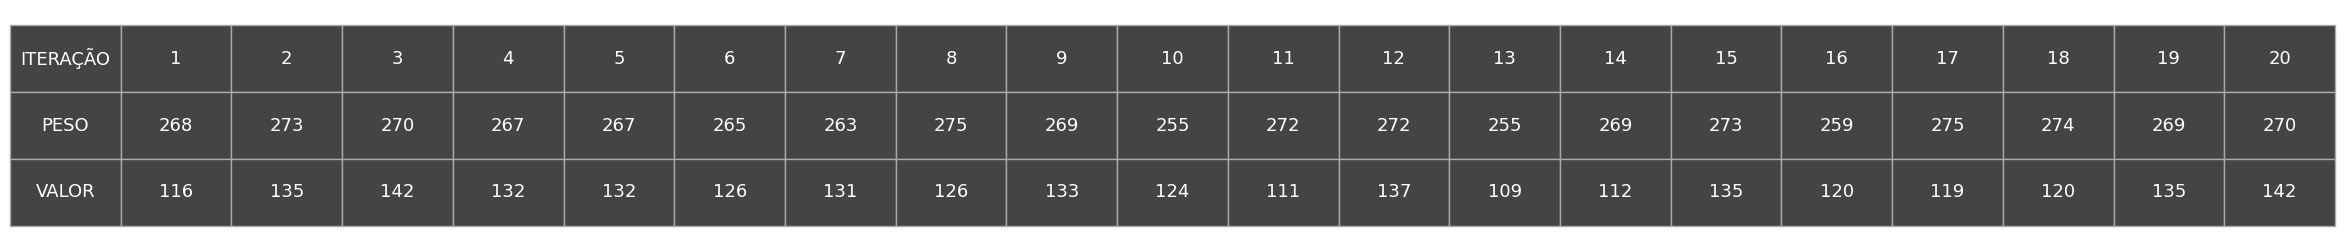


MELHOR SOLUÇÃO ENCONTRADA: [1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1] PESO: 270 VALOR: 142
TOTAL DE AVALIAÇÕES DA FUNÇÃO OBJETIVO EM TODAS AS 20 EXECUÇÕES: 1372


In [141]:
from typing import List
import random
import matplotlib.pyplot as plt

class Node:
    '''REPRESENTA UMA CANDIDATA À SOLUÇÃO'''

    #   PADRÃO:
    #   SOLUÇÃO VAZIA COM 15 POSIÇÕES PREENCHIDAS COM 0
    #   NÓ PAI: NÃO EXISTE
    def __init__(self, candidate: List = [0 for _ in range(15)], parent = None):
        self.candidate = self.validateCandidate(candidate)
        self.parent = parent

    def validateCandidate(self, candidate):
        '''VALIDA A SOLUÇÃO CANDIDATA'''

        for presentItem in candidate:

            #   SE O FORMATO DA SOLUÇÃO FOR INVÁLIDO RETORNA UMA CANDIDATA VAZIA COM 15 ITENS
            if not(presentItem != 0 or presentItem != 1):
                return [0 for _ in range(15)]

        return candidate

class Items:

    #   PADRÃO
    #   ITENS COM PESOS 63, 21, 2, 32, 13, 80, 19, 37, 56, 41, 14, 8, 32, 42 E 7
    #   ITENS COM VALORES 13, 2, 20, 10, 7, 14, 7, 2, 2, 4, 16, 17, 17, 3, 21
    def __init__(self, peso: List = [63, 21, 2, 32, 13, 80, 19, 37, 56, 41, 14, 8, 32, 42, 7],
                       valor: List = [13, 2, 20, 10, 7, 14, 7, 2, 2, 4, 16, 17, 17, 3, 21]):

        if len(peso) == len(valor):
            self.weight = peso
            self.value = valor

        else:
            self.weight = [63, 21, 2, 32, 13, 80, 19, 37, 56, 41, 14, 8, 32, 42, 7]
            self.value = [13, 2, 20, 10, 7, 14, 7, 2, 2, 4, 16, 17, 17, 3, 21]

class Knapsack:
    '''CLASSE QUE REPRESENTA UMA MOCHILA
        ATRIBUTOS:
        NODE (a configuração atual da mochila)
        ITEMS (as informações de peso e valor de cada item presente na mochila)
        CAPACITY (o peso máximo suportado pela mochila)
    '''

    def __init__(self, start: Node = Node(), items: Items = Items(), capacity: int = 275):
        '''UMA MOCHILA RECEBE COMO PARÂMETROS DE ENTRADA:
                UMA SOLUÇÃO CANDIDATA (EXEMPLO: [0, 1, 0, 1])
                UM OBJETO DE ITENS (EXEMPLO: peso=[63, 4, 10, 9], valor=[4, 3, 20, 90])
                A CAPACIDADE MÁXIMA DA MOCHILA
        '''
        self.start = start
        self.items = items

        self.capacity = capacity
        self.totalWeight = self.calculateTotalWeight()
        self.totalValue = self.calculateTotalValue()

    def calculateTotalWeight(self):
        '''CALCULA O PESO TOTAL DOS ITENS NA MOCHILA'''
        totalWeight = 0

        for index in range(len(self.items.weight)):

            #   SE O ITEM ATUAL ESTIVER NA MOCHILA
            if self.start.candidate[index] == 1:
                totalWeight += self.items.weight[index]

                #   SE A SOMA TOTAL ULTRAPASSAR A CAPACIDADE MÁXIMA INVALIDA O VALOR
                if not(self.isViable(totalWeight)):
                    return -1

        return totalWeight

    def calculateTotalValue(self):
        '''CALCULA O PESO TOTAL DOS ITENS NA MOCHILA'''
        totalValue = 0

        for index in range(len(self.items.value)):

            #   SE O ITEM ATUAL ESTIVER NA MOCHILA
            if self.start.candidate[index] == 1:
                totalValue += self.items.value[index]

                #   SE A SOMA TOTAL ULTRAPASSAR A CAPACIDADE MÁXIMA INVALIDA O VALOR
                if not(self.isViable(self.totalWeight)):
                    return -1

        return totalValue

    def isViable(self, totalWeight):
        '''DETERMINA SE A SOLUÇÃO É VIÁVEL, ISTO É, SE NÃO ULTRAPASSA A CAPACIDADE MÁXIMA DA MOCHILA'''

        if totalWeight != -1 and totalWeight <= self.capacity:
            return True

        return False

    def neighbours(self, node : Node):
        '''GERA A VIZINHANÇA DE SOLUÇÕES CANDIDATAS A PARTIR DA CANDIDATA ATUAL'''
        currentNode = node
        neighbourhood = []

        #   GERA OS VIZINHOS UM POR UM E DESCARTA OS VIZINHOS QUE ULTRAPASSAM A CAPACIDADE MÁXIMA
        for i in range(len(currentNode.candidate)):
            neighbour = []

            j = 0

            for j in range(0, i):
                neighbour.append(currentNode.candidate[j])

            j = i

            #   MOVIMENTO QUE ADICIONA UM ITEM
            if currentNode.candidate[i] == 0:
                neighbour.append(1)

            #   MOVIMENTO QUE REMOVE UM ITEM
            if currentNode.candidate[i] == 1:
                neighbour.append(0)

            for j in range(i + 1, len(currentNode.candidate)):
                neighbour.append(currentNode.candidate[j])

            childNode = Node(neighbour, currentNode)
            items = self.items
            capacity = self.capacity
            newKnapsack = Knapsack(childNode, items, capacity)

            #   SE A VIZINHA FOR VIÁVEL ADICIONA ELA À VIZINHANÇA
            if newKnapsack.isViable(newKnapsack.totalWeight):
                neighbourhood.append(newKnapsack)

        return neighbourhood

def imprimirItens(items : Items, capacity: int):

    print('ITEM\t\t', end='')
    for index in range(len(items.weight)):
        print(f'{index + 1}\t\t', end='')
    print()

    print('PESO\t\t', end='')
    for weight in items.weight:
        print(f'{weight}\t\t', end='')
    print()

    print('VALOR\t\t', end='')
    for value in items.value:
        print(f'{value}\t\t', end='')

    print()

    print(f'CAPACIDADE MÁXIMA DA MOCHILA: {capacity}')
    print()

def hillClimbing(knapsack : Knapsack, recordResults = False):
    '''
    SOLUCIONA O PROBLEMA DA MOCHILA UTILIZANDO O ALGORITMO SUBIDA DE ENCOSTA COM SUBIDA ÍNGREME (STEEPES-ASCENT)
    '''

    #   VERIFICA SE A SOLUÇÃO É VIÁVEL
    if knapsack.isViable(knapsack.totalWeight):
        initialCandidate = knapsack.start.candidate
        initialWeight = knapsack.totalWeight
        initialValue = knapsack.totalValue

        currentNode = knapsack.start
        currentCandidate = initialCandidate

        goalFunctionEvaluations = 0

        items = knapsack.items
        capacity = knapsack.capacity

        print(f'CONFIGURAÇÃO INICIAL DA MOCHILA: {initialCandidate} ')
        print(f'PESO: {initialWeight} ')
        print(f'VALOR: {initialValue}\n')

        goalFunctionEvaluations += 1

        currentKnapsack = knapsack

        #   GERAÇÃO DAS VIZINHAS VIÁEVIS
        neighbourhood = currentKnapsack.neighbours(currentNode)

        totalHighestValue = currentKnapsack.totalValue
        existsHighestValue = True

        while existsHighestValue:
            remainingEvals = len(neighbourhood)

            print(f'VIZINHANÇA DA CANDIDATA ATUAL: ')

            #   ESCOLHA DA VIZINHA COM O MAIOR VALOR TOTAL
            for neighbour in neighbourhood:

                #   EXPANDE A VIZINHANÇA DA CANDIDATA COM O MAIOR VALOR TOTAL
                neighbourhood = currentKnapsack.neighbours(currentNode)
                goalFunctionEvaluations += 1

                #   SE A VIZINHA ATUAL TIVER UM VALOR TOTAL MAIOR DO QUE O MAIOR VALOR ENCONTRADO
                if neighbour.totalValue > totalHighestValue:
                    currentKnapsack = neighbour
                    totalHighestValue = currentKnapsack.totalValue

                #   SE A VIZINHA ATUAL TIVER UM VALOR TOTAL IGUAL AO MAIOR VALOR ENCONTRADO (EMPATE POR VALOR)
                elif neighbour.totalValue == totalHighestValue:

                    #   SE A VIZINHA ATUAL TIVER O MENOR PESO TOTAL OU O MESMO PESO DA OUTRA (EMPATE POR PESO)
                    if neighbour.totalWeight <= currentKnapsack.totalWeight:
                        currentKnapsack = neighbour
                        totalHighestValue = currentKnapsack.totalValue

                    #   SE A OUTRA VIZINHA TIVER O MENOR PESO TOTAL
                    else:
                        totalHighestValue = neighbour.totalValue

                #   SE A VIZINHA ATUAL NÃO MELHORAR O RESULTADO
                else:
                    remainingEvals -= 1

                currentNode = currentKnapsack.start
                print(f'VIZINHA {neighbour.start.candidate}: ', end='')
                print(f'PESO: {neighbour.totalWeight} ', end='\t')
                print(f'VALOR: {neighbour.totalValue}')

            print()

            #   SE NÃO EXISTIR UMA MELHORA NO VALOR TOTAL
            if remainingEvals == 0:
                print(f'NÃO HÁ MAIS MELHORAS PARA A FUNÇÃO OBJETIVO! ENCERRANDO O ALGORITMO\n')
                existsHighestValue = False

            #   SE EXISTIR UMA MELHORA NO VALOR TOTAL
            else:
                print(f'CANDIDATA COM O MAIOR VALOR TOTAL SELECIONADA: {currentKnapsack.start.candidate} ')
                print(f'PESO: {currentKnapsack.totalWeight} ')
                print(f'VALOR: {currentKnapsack.totalValue}\n')

                goalFunctionEvaluations += 1

        if recordResults:
            goalFunctionEvaluationsList.append(goalFunctionEvaluations)

        print(f'NÚMERO DE AVALIAÇÕES DA FUNÇÃO OBJETIVO: {goalFunctionEvaluations}\n')

        #   TRATADO PELO MATPLOTLIB
        if recordResults:
            weights.append(currentKnapsack.totalWeight)
            values.append(currentKnapsack.totalValue)

        return currentKnapsack

    #   SE NÃO FOR UMA SOLUÇÃO VIÁVEL
    else:
        zerolist = [0] * len(knapsack.items.value)
        print('CANDIDATA INVIÁVEL: ', end='')

        inviableCandidate = knapsack.start.candidate
        print(f'{inviableCandidate}\n')

        #   RETORNA UMA MOCHILA VAZIA SEM ITENS PARA SELEÇÃO
        return Knapsack(Node(zerolist), Items(zerolist, zerolist), 0)

tableRows = []
weights = []
values = []

tableColumns = []
goalFunctionEvaluationsList = []
def randomRestartHillClimbing(restarts: int = 1,
                              capacity: int = 275,
                              itemsToShuffle: Items = Items([63, 21, 2, 32, 13, 80, 19, 37, 56, 41, 14, 8, 32, 42, 7],
                                                           [13, 2, 20, 10, 7, 14, 7, 2, 2, 4, 16, 17, 17, 3, 21]),
                              recordResults = True):
    '''EXECUTA O ALGORITMO SUBIDA DE ENCOSTA COM REINÍCIOS ALEATÓRIOS
       PARÂMETROS DE ENTRADA:
       knapsack => UM OBJETO KNAPSACK QUE REPRESENTA UMA MOCHILA
       (COM SUA RESPECTIVA CONFIGURAÇÃO, DOMÍNIO DE PESOS E VALORES PARA OS ITENS E SUA CAPACIDADE MÁXIMA DE PESO)
       restarts => O NÚMERO DE REINÍCIOS ALEATÓRIOS FEITOS. SE NÃO FOR PASSADO COMO PARÂMETRO IRÁ SE COMPORTAR
       COMO UM ALGORITMO SUBIDA DE ENCOSTA COM SUBIDA ÍNGREME (STEEPEST-ASCENT), COM A DIFERENÇA QUE
       A CONFIGURAÇÃO INICIAL DA MOCHILA SERÁ DEFINIDA DE FORMA ALEATÓRIA E ELE SERÁ EXECUTADO
       ATÉ CHEGAR EM UM PROVÁVEL MÁXIMO LOCAL E NÃO INDO ALÉM DISSO.
    '''

    #   DADOS SOBRE O POSSÍVEL MÁXIMO GLOBAL
    localMaxima = 0
    bestValue = 0

    iterations = 1

    currentGlobalMaximaKnapsack = None

    #   TRATADO PELO MATPLOTLIB
    tableColumns.append('ITERAÇÃO')

    for counter in range(restarts):
        tableColumns.append(counter + 1)

    weights.append('PESO')
    values.append('VALOR')

    #   REALIZA AS ITERAÇÕES SOBRE AS VÁRIAS SOLUÇÕES UMA DE CADA VEZ
    while iterations <= restarts:
        print(f'============================================= {iterations}ª ITERAÇÃO =============================================')

        #   CRIA UMA MOCHILA QUE PODE SER OU NÃO VIÁVEL
        currentInitialKnapsack = generateCurrentInitialKnapsack(itemsToShuffle, capacity)
        currentLocalMaximaKnapsack = hillClimbing(currentInitialKnapsack, recordResults)

        totalWeight = currentInitialKnapsack.totalWeight

        #   GARANTE A VIABILIDADE DA SOLUÇÃO PARA CADA REINÍCIO/ITERAÇÃO,
        #   TENTANDO SEMPRE GERAR UMA NOVA CANDIDATA INICIAL
        #   ATÉ QUE ELA SEJA VIÁVEL
        while not(currentLocalMaximaKnapsack.isViable(totalWeight)):
            print(f'TENTANDO GERAR UMA NOVA CANDIDATA INICIAL VIÁVEL:\n')

            currentInitialKnapsack = generateCurrentInitialKnapsack(itemsToShuffle, capacity)
            currentLocalMaximaKnapsack = hillClimbing(currentInitialKnapsack, recordResults)

            totalWeight = currentInitialKnapsack.totalWeight

        localMaxima = currentLocalMaximaKnapsack.totalValue

        if localMaxima > bestValue:
            bestValue = localMaxima
            currentGlobalMaximaKnapsack = currentLocalMaximaKnapsack

            totalWeight = currentGlobalMaximaKnapsack.totalWeight
            totalValue = currentGlobalMaximaKnapsack.totalValue

        print(f'MELHOR CANDIDATA ATÉ O MOMENTO: {currentGlobalMaximaKnapsack.start.candidate} PESO: {currentGlobalMaximaKnapsack.totalWeight}\tVALOR: {currentGlobalMaximaKnapsack.totalValue}\n')

        iterations += 1

    #   TRATADO PELO MATPLOTLIB
    tableRows.append(tableColumns)
    tableRows.append(weights)
    tableRows.append(values)

    fig, ax = plt.subplots(figsize=(len(tableColumns) - 1, len(tableRows)))
    ax.axis('off')

    table = ax.table(cellText=tableRows,
                     cellLoc='center',
                     loc='center')

    table.set_fontsize(40)
    table.scale(1.5, 4.0)

    for (row, column), cell in table.get_celld().items():
        cell.set_facecolor('#444444')
        cell.get_text().set_color('white')
        cell.set_edgecolor('#aaaaaa')

    print('TABELA COM O PESO E O VALOR FINAL DE CADA REINÍCIO:')

    plt.show()

    return currentGlobalMaximaKnapsack

def shuffleItems(itemsToShuffle: Items):
    '''EMBARALHA A ORDEM DOS ITENS, MANTENDO A CORRESPONDÊNCIA ENTRE OS PESOS E OS VALORES'''

    combined = list(zip(itemsToShuffle.weight, itemsToShuffle.value))
    random.shuffle(combined)

    weights, values = zip(*combined)

    weightsShuffled = list(weights)
    valuesShuffled = list(values)

    return Items(weightsShuffled, valuesShuffled)

def generateCurrentInitialKnapsack(itemsToShuffle: Items, capacity: int = 275):

        #   CRIA UMA CANDIDATA VAZIA
        currentCandidate = [0] * len(itemsToShuffle.value)

        #   EMBARALHA A ORDEM DOS ITENS
        shuffledItems = shuffleItems(itemsToShuffle)

        #   PARA CADA ITEM, SORTEIA COM UMA CHANCE DE 50% DE ADICIONÁ-LO
        for index in range(len(currentCandidate)):
            currentCandidate[index] = random.randint(0, 1)

        print(f'SEED USADA: None (relógio do sistema (padrão))\n')

        currentInitialKnapsack = Knapsack(Node(currentCandidate), shuffledItems, capacity)

        print('ITENS EMBARALHADOS:')
        imprimirItens(currentInitialKnapsack.items, capacity)

        return currentInitialKnapsack

#   ETAPA 2 - REPRESENTAÇÃO E AVALIAÇÃO DE UMA SOLUÇÃO

#   TESTE 1 - MOCHILA VAZIA
candidataInicial = Node([0] * 15)
mochila = Knapsack(candidataInicial)
configuracao = mochila.start.candidate
pesoTotal = mochila.totalWeight
valorTotal = mochila.totalValue
capacidade = mochila.capacity

print(f'=================================TESTES DA ETAPA 2================================')

print(f'ITENS DISPONÍVEIS')
imprimirItens(mochila.items, capacidade)
print(f'=================================MOCHILA VAZIA====================================')

print(f'CONFIGURAÇÃO ATUAL DA MOCHILA: {configuracao}')
print(f'PESO: {pesoTotal}')
print(f'VALOR: {valorTotal}')

print()

#   TESTE 2 - CANDIDATA VIÁVEL
candidataInicial = Node([1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1])
mochila = Knapsack(candidataInicial)
configuracao = mochila.start.candidate
pesoTotal = mochila.totalWeight
valorTotal = mochila.totalValue

print(f'=================================CANDIDATA VIÁVEL=================================')
print(f'CONFIGURAÇÃO ATUAL DA MOCHILA: {configuracao}')
print(f'PESO: {pesoTotal}')
print(f'VALOR: {valorTotal}')

print()

#   TESTE 2 - CANDIDATA QUE ULTRAPASSA A CAPACIDADE MÁXIMA
candidataInicial = Node([0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1])
mochila = Knapsack(candidataInicial)
configuracao = mochila.start.candidate
pesoTotal = mochila.totalWeight
valorTotal = mochila.totalValue

print(f'=======CANDIDATA QUE ULTRAPASSA A CAPACIDADE MÁXIMA DA MOCHILA====================')
print(f'CONFIGURAÇÃO ATUAL DA MOCHILA: {configuracao}')
print(f'PESO: {pesoTotal if pesoTotal != -1 else 'inválido (peso excede a capacidade)'}')
print(f'VALOR: {valorTotal if pesoTotal != -1 else 'inválido (peso excede a capacidade)'}')

print('\n')

#   ETAPA 3 - DEFINIÇÃO DA VIZINHANÇA

print(f'=================================TESTES DA ETAPA 3================================')
candidataInicial = Node([0, 1, 1, 0])
items = Items([63, 21, 2, 32], [13, 2, 20, 10])
capacidade = 70
mochila = Knapsack(candidataInicial, items, capacidade)
configuracao = mochila.start.candidate
pesoTotal = mochila.totalWeight
valorTotal = mochila.totalValue

print(f'ITENS DISPONÍVEIS')
imprimirItens(mochila.items, capacidade)

print(f'=================================CANDIDATA VIÁVEL=================================')
print(f'CONFIGURAÇÃO ATUAL DA MOCHILA: {configuracao} ', end='')
print(f'PESO: {pesoTotal} ', end='')
print(f'VALOR: {valorTotal}\n')
print(f'VIZINHANÇA DA CANDIDATA ATUAL: ')
vizinhanca = mochila.neighbours(candidataInicial)
print(f'TOTAL DE VIZINHAS: {len(vizinhanca)}\n')

for neighbour in vizinhanca:
    print(f'VIZINHA {neighbour.start.candidate}:', end='  ')
    print(f'PESO: {neighbour.totalWeight}', end='  ')
    print(f'VALOR: {neighbour.totalValue}', end='  ')
    print(f'PAI DESTA VIZINHA: {neighbour.start.parent.candidate}')
print()

#   ETAPA 4 - IMPLEMENTAÇÃO DO HILL CLIMBING
print(f'=================================TESTES DA ETAPA 4================================')

candidataInicial = Node([0, 0, 1, 0, 0, 0])
items = Items([80, 19, 37, 56, 41, 42], [14, 7, 2, 2, 4, 3])
capacidade = 195                                                                            #   CAPACIDADE ARBITRÁRIA
mochila = Knapsack(candidataInicial, items, capacidade)

print(f'ITENS DISPONÍVEIS')
imprimirItens(mochila.items, capacidade)

print(f'==================EXECUTANDO O ALGORITMO HILL CLIMBING (SUBIDA DE ENCOSTA):===========')
mochilaComMaiorValorTotal = hillClimbing(mochila)

candidataComMaiorValor = mochilaComMaiorValorTotal.start.candidate
pesoTotal = mochilaComMaiorValorTotal.totalWeight
valorTotal = mochilaComMaiorValorTotal.totalValue

print(f'MOCHILA COM MAIOR VALOR ENCONTRADO: {candidataComMaiorValor} ', end='')
print(f'PESO: {pesoTotal} ', end='')
print(f'VALOR: {valorTotal}\n')

#   CALCULA O TOTAL DE MOVIMENTOS REALIZADOS (ADICIONANDO ITENS)
configuracaoInicial = mochilaComMaiorValorTotal
movimentos = []
numeroDeMovimentos = 0

noAtual = configuracaoInicial.start

while noAtual.parent is not None:
    movimentos.append(noAtual)

    numeroDeMovimentos += 1
    noAtual = noAtual.parent

movimentos.reverse()

print(f'NÚMERO DE MOVIMENTOS: {numeroDeMovimentos}')
print(f'CONFIGURAÇÃO INICIAL: {movimentos[0].parent.candidate}')
print(f'MOVIMENTOS: ', end='')

for estadoAtual in movimentos:
    print(f'{estadoAtual.candidate} => ', end='')

#   ETAPA 5 - ACRESCENTANDO REINÍCIOS ALEATÓRIOS

print('\n')
print(f'=================================TESTES DA ETAPA 5================================')

candidataInicial = Node([0] * 15)
items = Items([63, 21, 2, 32, 13, 80, 19, 37, 56, 41, 14, 8, 32, 42, 7],
              [13, 2, 20, 10, 7, 14, 7, 2, 2, 4, 16, 17, 17, 3, 21])
capacidade = 275                                                                            #   CAPACIDADE ARBITRÁRIA
mochila = Knapsack(candidataInicial, items, capacidade)

print(f'ITENS DISPONÍVEIS')
imprimirItens(mochila.items, capacidade)

print(f'==================EXECUTANDO O ALGORITMO HILL CLIMBING (SUBIDA DE ENCOSTA) COM REINÍCIOS ALEATÓRIOS (RANDOM RESTART):===========\n')
melhorSolucao = randomRestartHillClimbing(20)
configuracao = melhorSolucao.start.candidate
pesoTotal = melhorSolucao.totalWeight
valorTotal = melhorSolucao.totalValue

print(f'\nMELHOR SOLUÇÃO ENCONTRADA: {configuracao} ', end='')
print(f'PESO: {pesoTotal} ', end='')
print(f'VALOR: {valorTotal}')

totalGoalFunctionEvaluations = 0
for evals in goalFunctionEvaluationsList:
    totalGoalFunctionEvaluations += evals

numeroDeExecucoes = len(tableColumns) - 1

print(f'TOTAL DE AVALIAÇÕES DA FUNÇÃO OBJETIVO EM TODAS AS {numeroDeExecucoes} EXECUÇÕES: {totalGoalFunctionEvaluations}')

<h1><b><u>ETAPA 1</u></b></h1>
<h2><b>1. Quais seleções de itens respeitam a capacidade?</b></h2>
<p>REPRESENTAÇÃO DOS ITENS NA FORMA <b>(PESO, VALOR)</b>:</p>
<p><b>SELEÇÕES COM 1 ITEM:</b></p>
<p>(63, 13)</p>
<p>(21, 2)</p>
<p>(2, 20)</p>
<p>(32, 10)</p>
<br>
<p><b>SELEÇÕES COM 2 ITENS:</b></p>
<p>(2, 20), (32, 10)</p>
<p>(21, 2), (32, 10)</p>
<p>(21, 2), (2, 20)</p>
<p>(63, 13), (2, 20)</p>
<br>
<p><b>SELEÇÃO COM 3 ITENS:</b></p>
<p>(21, 2), (2, 20), (32, 10)</p>
<br>

<h2><b>2. Qual delas tem o maior valor total?</b></h2>
<p><b>(63, 13), (2, 20)</b> (PESO TOTAL = <b>65</b> VALOR TOTAL = <b>33</b>)</p>
<br>

<h2><b>3. Calcule a razão valor/peso de cada item. Depois, tente adicionar os itens da maior para a menor razão, sempre que couberem. A seleção obtida é a melhor que você encontrou na pergunta anterior?</b></h2>
<p>
RAZÃO<sub>ITEM1</sub> = <b>0.21</b> (13 / 63)<br>
RAZÃO<sub>ITEM2</sub> = <b>0.1</b> (2 / 21)<br>
RAZÃO<sub>ITEM3</sub> = <b>10</b> (20 / 2)<br>
RAZÃO<sub>ITEM4</sub> = <b>0.31</b> (10 / 32)<br><br>
</p>

<p><u><b>SELEÇÃO ADICIONANDO OS ITENS PELA ORDEM DE RAZÃO</b></u><br>
(2, 20)<br>
(2, 20), (32, 10)<br>
(2, 20), (32, 10), (21, 2)<br><br>

PESO TOTAL = <b>55</b> VALOR TOTAL = <b>32</b>
</p>

<p>Não é a melhor solução encontrada na pergunta anterior.<br><br>

<h2><b>4. O que esse resultado mostra sobre usar uma regra simples para tomar cada decisão separadamente?</b></h2>
<p>Mostra que a <b>regra não garante</b> que o algoritmo encontre a melhor solução possível.</p>
<br>

<h1><b><u>ETAPA 2</u></b></h1>
<p><b>DETALHES NA SAÍDA DO CÓDIGO</b></p>

<br>

<h1><b><u>ETAPA 3</u></b></h1>
<p><b>DETALHES NA SAÍDA DO CÓDIGO</b></p>
<br>

<h1><b><u>ETAPA 4</u></b></h1>
<h2><b>O algoritmo fez algum movimento?</b></h2>
<p>Sim, fez 3 movimentos no total.</p>
<br>

<h2><b>A solução encontrada parece boa?</b></h2>
<p>Sim, porém pode não ser a melhor solução de todas (ótimo global).</p>
<br>

<h2><b>Por que ela pode ser um ótimo local quando usamos essa vizinhança?</b></h2>
<p>Porque o algoritmo Hill Climbing com subida íngreme (<i>steepest-ascent</i>) que foi implementado considera somente aas candidatas que produzem uma melhora no resultado da função objetivo, fazendo com que o algoritmo fique preso em um <b>máximo local</b>, encerrando sua execução de forma precoce, não podendo fazer movimentos que levem o algoritmo a convergir para o ótimo global em algum momento.</p>
<br>

<h2><b>Permitir a troca simultânea de um item por outro mudaria as vizinhas disponíveis?</b></h2>
<p>Sim. Considerando que a candidata inicial [0, 0, 1, 0, 0, 0] seja substituída pela candidata inicial [0, 1, 0, 0, 0, 0], das 6 vizinhas viáveis apenas 4 delas mudaram, as outras 2 manteriam seu peso e valor total ao trocar o item 8 pelo item 7.</p>
<br>

<h2><b>EXEMPLO COM MAIS DETALHES NA SAÍDA DO CÓDIGO</b></h2>

<h1><b><u>ETAPA 5</u></b></h1>
<p>O melhor resultado encontrado foi para uma mochila com valor <b>142</b> e peso <b>270</b>, porém, para alguns testes o melhor valor encontrado foi <b>menor que 142</b>, ou seja, o máximo global <b>não é garantido</b>.</p>

<br>

<h1>Simulated Annealing (Têmpera Simulada)</h1>